In [1]:
from pydantic import BaseModel
from typing import List
from langgraph.graph import StateGraph, START, END

class State(BaseModel):
    resume_path: str
    job_path: str

    user_profile: str = None
    job_profile: str = None
    resume_score: float = None

    questions: List[str] = []
    answers: List[str] = []
    current_question: str = ""

    waiting_for_answer: bool = False
    round: int = 0
    max_rounds: int = 5


In [2]:
def inputs(state: State):
    pass

def resume_screening(state: State):
    pass

def generate_question(state: State):
    state.current_question = "placeholder question"
    state.questions.append(state.current_question)

    state.waiting_for_answer = True
    state.round += 1

def evaluate_answer(state: State):
    state.waiting_for_answer = False

def condition(state: State):

    if state.waiting_for_answer:
        return None

    if state.round >= state.max_rounds:
        return True

    return False

def generate_score(state: State):
    state.resume_score = 0.0

def resume_enhancement(state: State):
    pass


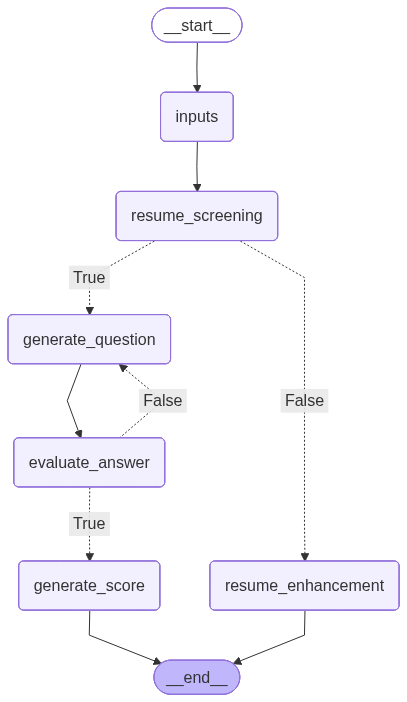

In [4]:
workflow = StateGraph(State)

workflow.add_node('inputs', inputs)
workflow.add_node('resume_screening', resume_screening)
workflow.add_node('generate_question', generate_question)
workflow.add_node('evaluate_answer', evaluate_answer)
workflow.add_node('generate_score', generate_score)
workflow.add_node('resume_enhancement', resume_enhancement)

workflow.add_edge(START, 'inputs')
workflow.add_edge('inputs', 'resume_screening')


workflow.add_conditional_edges('resume_screening', condition, {
    True: 'generate_question',
    False: 'resume_enhancement'
})

workflow.add_edge('resume_enhancement', END)

workflow.add_edge('generate_question', 'evaluate_answer')


workflow.add_conditional_edges('evaluate_answer', condition, {
    True: 'generate_score',
    False: 'generate_question'
})

workflow.add_edge('generate_score', END)

workflow.compile()
